In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import varray as va
import ldax_analysis as lan
plt.style.use('../style.mplstyle')
rq_path = '/mnt/drive2/TPC_RQs/proc_settings_amp50V_v004/'

RQ_names = [
    'p_phe',
    'p_aft',
    'p_bnds',
    'e_timestamps',
    'ss_s1_phe_ch',
    'ss_s1_phe',
    'ss_s1_aft',
    'ss_s1_mhf',
    'ss_s2_phe_ch',
    'ss_s2_phe',
    'ss_s2_aft',
    'ss_s2_drift_time',
    'ss_bad_phe',
    'ss_e_timestamps',
    'ss_s2_x_raw',
    'ss_s2_y_raw',
    'ss_s2_r_raw',
]

In [5]:
date = '2026-07-14-0846'
files = []
for i in range(50):
    if i < 10:
            file = date + "_00000" + str(i)
    elif i < 100:
        file = date + "_0000" + str(i)
    else:
        file = date + "_000" + str(i)

    files.append(rq_path+file+'_RQ.vrz')
d = lan.concat_RQ_files([f'{file}' for file in files], RQ_names)

In [6]:
d['time_from_acq_start'] = d['e_timestamps'] - d['e_timestamps'][0]
d['ss_s2_top_phe'] = np.sum(d['ss_s2_phe_ch'][:16], axis=0)
d['ss_s2_bot_phe'] = np.sum(d['ss_s2_phe_ch'][-16:], axis=0)
d['ss_s2_tba'] = (d['ss_s2_top_phe'] - d['ss_s2_bot_phe'])/d['ss_s2_phe']
d['ss_good_phe'] = d['ss_s2_phe'] + d['ss_s1_phe']
d['ss_s2_width595'] = d['ss_s2_aft'][:,6] - d['ss_s2_aft'][:,0]
d['ss_trig_timestamp'] = (d['ss_e_timestamps'] - d['ss_e_timestamps'][0])*10**-8
d['trig_timestamp'] = (d['e_timestamps'] - d['e_timestamps'][0])*10**-8
d['p_width595'] = d['p_aft'][:,6] - d['p_aft'][:,0]

In [7]:
def plot2d(
    x,
    y,
    x_range=None,
    y_range=None,
    x_bins=50,
    y_bins=50,
    flag_log=False,
    flag_mask=True,
    y_log_scale=False,
    cmap=None,
):
    if cmap is None:
        cmap = matplotlib.cm.viridis

    if x_range is None:
        x_range = [x.min(), x.max()]
    if y_range is None:
        y_range = [y.min(), y.max()]

    if x_range[1] < x_range[0]:
        x_range = x_range[::-1]
    if y_range[1] < y_range[0]:
        y_range = y_range[::-1]

    # x bin edges (always linear)
    x_xe = np.linspace(x_range[0], x_range[1], x_bins + 1)

    # y bin edges
    if y_log_scale:
        if y_range[0] <= 0:
            raise ValueError("y_range must be positive for logarithmic y scale.")
        x_ye = np.logspace(
            np.log10(y_range[0]),
            np.log10(y_range[1]),
            y_bins + 1,
        )
    else:
        x_ye = np.linspace(y_range[0], y_range[1], y_bins + 1)

    # Histogram
    n = np.histogramdd(np.column_stack((x, y)), bins=[x_xe, x_ye])[0]

    if flag_mask:
        n_max = n[n > 0].max()
        n_min = n[n > 0].min()
        n = np.ma.masked_where(n <= 0, n)
    else:
        if flag_log:
            n[n <= 0] = 0.1
        n_max = n.max()
        n_min = n.min()

    # Color normalization
    if flag_log:
        n_Norm = matplotlib.colors.LogNorm(vmin=n_min, vmax=n_max)
    else:
        n_Norm = matplotlib.colors.Normalize(vmin=n_min, vmax=n_max)

    h = plt.pcolormesh(
        x_xe,
        x_ye,
        n.T,
        norm=n_Norm,
        cmap=cmap,
        shading="auto",
    )

    h.set_edgecolor("face")
    h.set_linewidth(0.001)

    if y_log_scale:
        plt.yscale("log")

    if flag_log and not flag_mask:
        cMax = h.get_clim()[1]
        h.set_clim((0.8, cMax))

    return n

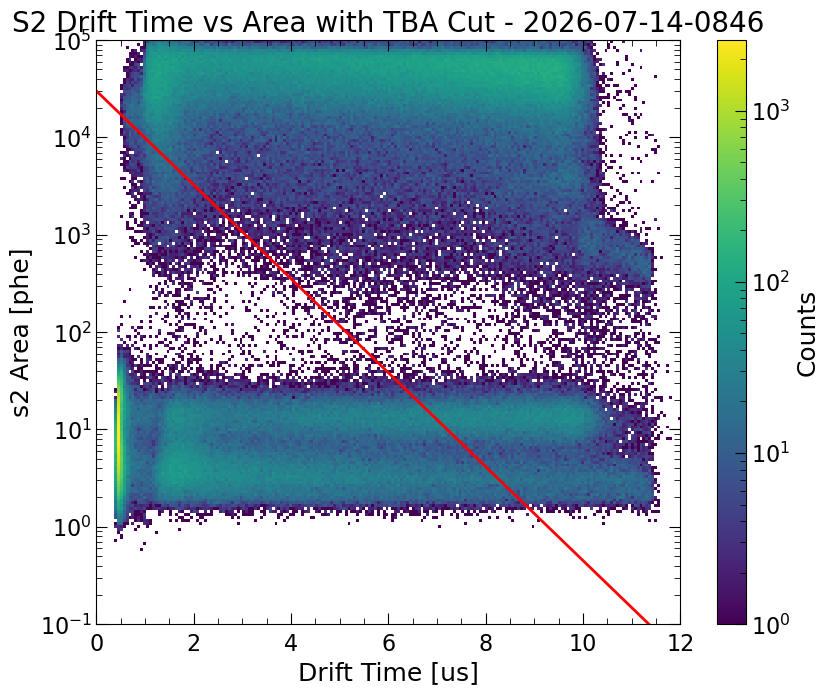

In [8]:
plt.figure(figsize=(10,8))
plot2d(d['ss_s2_drift_time']/100, d['ss_s2_phe'], (0,12), (0.1, 1e5), x_bins=200, y_bins=200, flag_log=True, y_log_scale=True)
x = np.linspace(0, 12, 100)
y = 3*10**4*np.exp(-x/0.9)
plt.plot(x, y, color='red')
#plt.yscale('log')
plt.xlim(0, 12)
#plt.axhline(y=1e3, color='red')
plt.xlabel("Drift Time [us]")
plt.ylabel("s2 Area [phe]")
plt.title("S2 Drift Time vs Area with TBA Cut - " + date)
plt.colorbar(label="Counts")
plt.show()
d['ss_s2_phe_corrected'] = d['ss_s2_phe'] * np.exp(d['ss_s2_drift_time']/100)

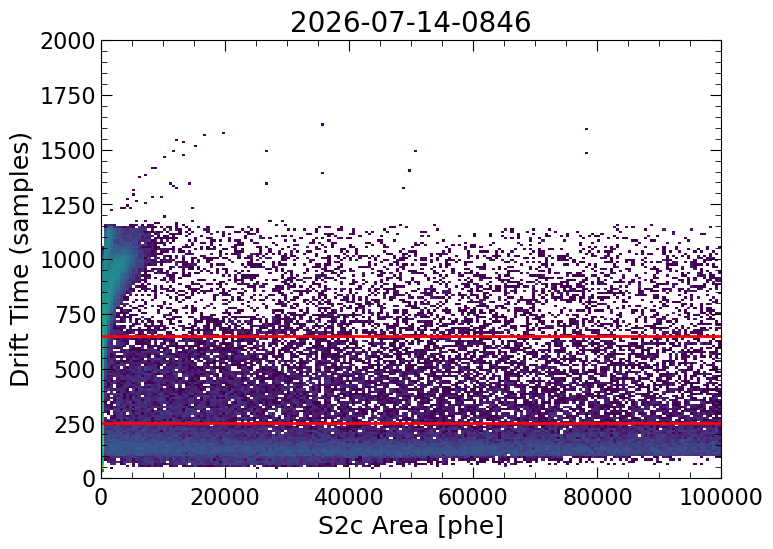

In [15]:
drift_time_cutoffs = [250, 650]
d['ss_s2_phe_corrected'] = d['ss_s2_phe'] * np.exp(d['ss_s2_drift_time']/180)

plot2d(d['ss_s2_phe_corrected'], d['ss_s2_drift_time'], (0,1e5), (0, 2e3), x_bins=200, y_bins=200, flag_log=True)
plt.xlabel("S2c Area [phe]")
plt.ylabel("Drift Time (samples)")
plt.axhline(y=drift_time_cutoffs[0], color='red')
plt.axhline(y=drift_time_cutoffs[1], color='red')
plt.title(date)
plt.show()
d['drift_time_cut'] = ((d['ss_s2_drift_time'] < drift_time_cutoffs[1]) & (d['ss_s2_drift_time'] > drift_time_cutoffs[0]))

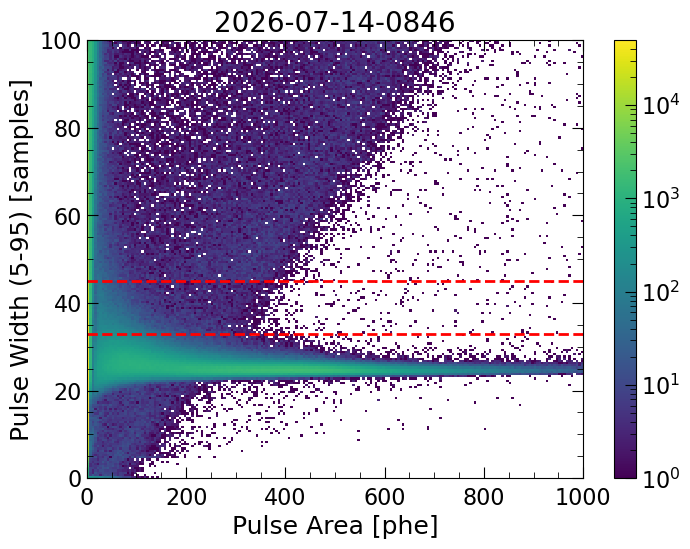

In [10]:
#Plots for cut verification and checks
plot2d(d['p_phe'].flatten(), d['p_width595'].flatten(), (0,1e3), (0, 1e2), x_bins=200, y_bins=200, flag_log=True)
plt.colorbar()
#plt.xlim(0, 200)
plt.xlabel("Pulse Area [phe]")
plt.ylabel("Pulse Width (5-95) [samples]")
plt.axhline(y=33, color='red', linestyle="--")
plt.axhline(y=45, color='red', linestyle="--")
plt.title(date)
#plt.ticklabel_format(axis='both', style='sci', scilimits=(3,5))
plt.show()
d['pulse_width_cut'] = (d['ss_s2_width595'] < 45)

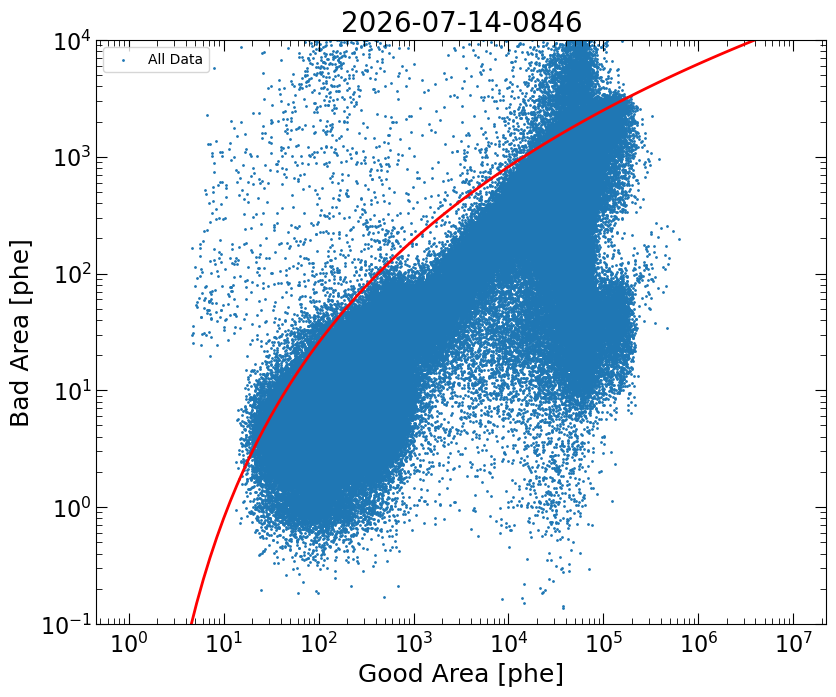

In [11]:
bad_area = d['ss_bad_phe']
good_area = d['ss_good_phe']
plt.figure(figsize=(10,8))
plt.scatter(good_area, bad_area, s=1, label='All Data')
plt.plot(np.logspace(0.01,7,100), 0.8*np.log10(np.logspace(0.01,7,100))**5, color='red')
plt.legend()
plt.axhline(y=1e-2, color='red')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Good Area [phe]")
plt.ylabel("Bad Area [phe]")
plt.title(date)
plt.ylim(1e-1, 1e4)
#plt.xlim(5e1, 4e2)
d['bad_area_cut'] = ((d['ss_bad_phe'] < 0.8*np.log10(d['ss_good_phe'])**5) & (d['ss_bad_phe'] > 1e-2))

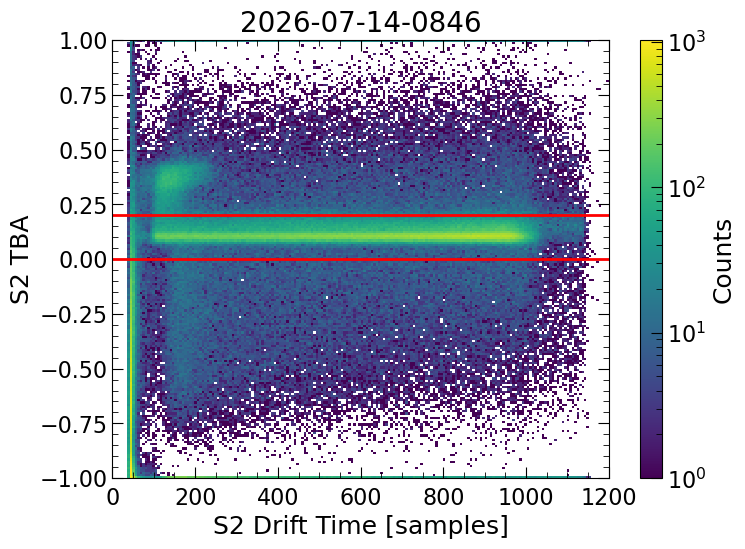

In [12]:
pulseS2TBACutoffs = [0., 0.2]

plot2d(d['ss_s2_drift_time'], d['ss_s2_tba'], (0,1.2e3), (-1, 1), x_bins=200, y_bins=200, flag_log=True)
plt.xlabel("S2 Drift Time [samples]")
plt.ylabel("S2 TBA")
plt.axhline(y=pulseS2TBACutoffs[0], color='red')
plt.axhline(y=pulseS2TBACutoffs[1], color='red')
plt.title(date)
plt.colorbar(label="Counts")
plt.show()
d['tba_cut'] = ((d['ss_s2_tba'] < pulseS2TBACutoffs[1]) & (d['ss_s2_tba'] > pulseS2TBACutoffs[0]))

/tmp/ipykernel_1292155/36025820.py:2: RuntimeWarning: divide by zero encountered in power
  plt.plot(np.linspace(0,1000,100), 1.3*np.linspace(0,1000,100)**-0.7+0.08, color='red')


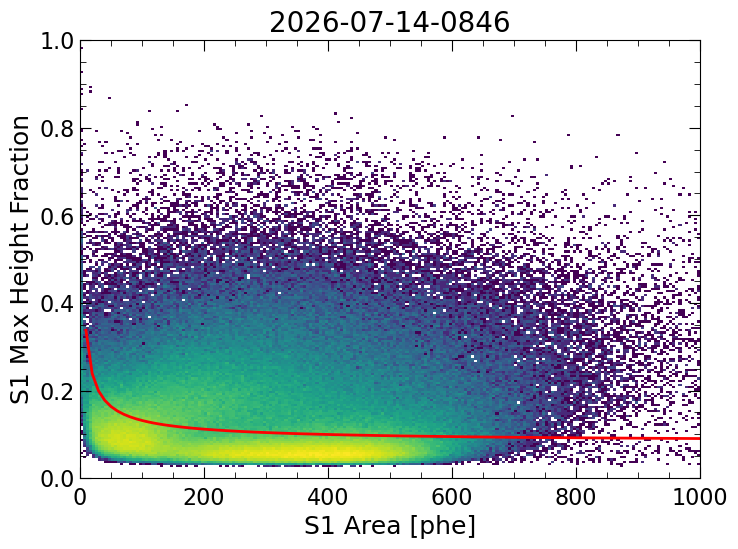

/tmp/ipykernel_1292155/36025820.py:7: RuntimeWarning: invalid value encountered in power
  d['mhf_cut'] = (d['ss_s1_mhf'] < 1.3*d['ss_s1_phe']**-0.7+0.08)


In [13]:
plot2d(d['ss_s1_phe'], d['ss_s1_mhf'], (0,1e3), (0, 1), x_bins=200, y_bins=200, flag_log=True)
plt.plot(np.linspace(0,1000,100), 1.3*np.linspace(0,1000,100)**-0.7+0.08, color='red')
plt.xlabel("S1 Area [phe]")
plt.ylabel("S1 Max Height Fraction")
plt.title(date)
plt.show()
d['mhf_cut'] = (d['ss_s1_mhf'] < 1.3*d['ss_s1_phe']**-0.7+0.08)

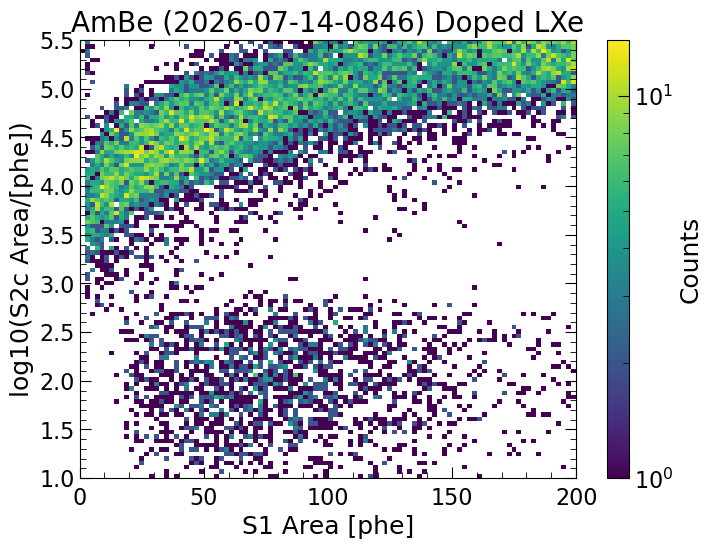

In [16]:
master_cut = d['mhf_cut'] & d['drift_time_cut'] & d['tba_cut'] & d['bad_area_cut']
s1_area_cut = d['ss_s1_phe'][master_cut]
s2_area_cut = d['ss_s2_phe_corrected'][master_cut]
plot2d(s1_area_cut, np.log10(s2_area_cut), (0,2e2), (1, 5.5), x_bins=100, y_bins=100, flag_log=True)
plt.colorbar(label="Counts")
#plt.ticklabel_format(axis='both', style='sci', scilimits=(3,1))
plt.xlabel("S1 Area [phe]")
plt.ylabel("log10(S2c Area/[phe])")
plt.title("AmBe (" + date + ") Doped LXe")
plt.show()

(100, 100)


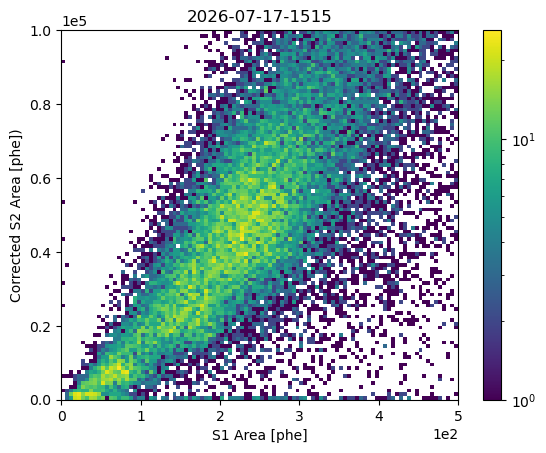

In [ ]:
plot2d(s1_area_cut, s2_area_cut, (0,5e2), (0, 1e5), x_bins=100, y_bins=100, flag_log=True)
plt.colorbar()
plt.ticklabel_format(axis='both', style='sci', scilimits=(2,5))
plt.xlabel("S1 Area [phe]")
plt.ylabel("Corrected S2 Area [phe])")
plt.title(date)
plt.show()

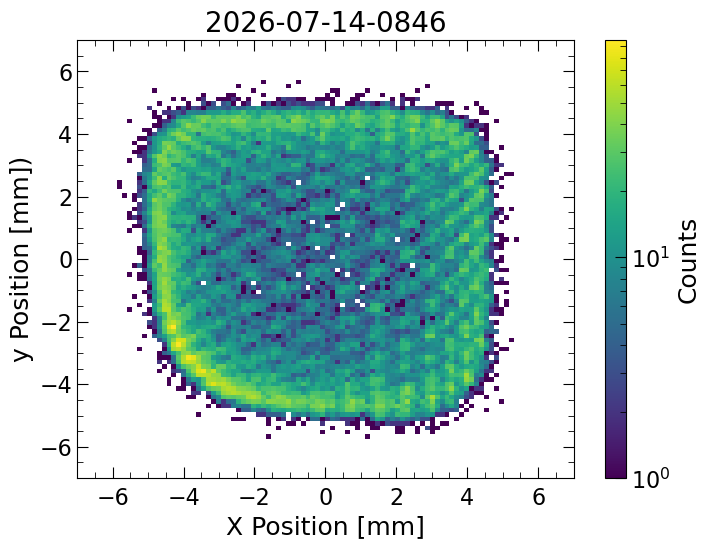

In [23]:
master_cut = d['mhf_cut'] & d['drift_time_cut'] & d['tba_cut'] & d['bad_area_cut']
plot2d(d['ss_s2_x_raw'][master_cut & (d['ss_s2_phe'] > 5e2)], d['ss_s2_y_raw'][master_cut & (d['ss_s2_phe'] > 5e2)], (-7, 7), (-7, 7), x_bins=100, y_bins=100, flag_log=True)
plt.colorbar(label='Counts')
#plt.ticklabel_format(axis='both', style='sci', scilimits=(2,5))
plt.xlabel("X Position [mm]")
plt.ylabel("y Position [mm])")
plt.title(date)
plt.show()